In [1]:
"""
╔══════════════════════════════════════════════════════════════╗
║  ReviewGuard — Phase 4b: Manual Ring Validation             ║
║  Qualitative validation of network-detected fake rings      ║
║  Goal: Compute Precision@K on top flagged reviewers         ║
╚══════════════════════════════════════════════════════════════╝
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from collections import Counter

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

os.makedirs("outputs/validation", exist_ok=True)

print("✅ Phase 4b Setup Complete!")
print(f"   Working dir: {os.getcwd()}")

✅ Phase 4b Setup Complete!
   Working dir: C:\Users\diyas\OneDrive\Desktop\reviewguard


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 1: LOAD DATA
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  STEP 1: LOADING DATA")
print("=" * 60)

# Load master dataset
df = pd.read_csv("data/processed/reviews_cleaned.csv", low_memory=False)
HIGH_QUALITY = ["amazon2", "amazon4", "amazon5"]
df = df[df["source_dataset"].isin(HIGH_QUALITY)].copy()
df = df.reset_index(drop=True)
df["review_id"] = range(len(df))
df["is_recommended"] = df["is_recommended"].astype(bool)
df["review_date_parsed"] = pd.to_datetime(df["review_date"], errors="coerce")

# Load network scores
reviewer_scores = pd.read_csv("data/graphs/reviewer_network_scores.csv")

# Get top 30 suspicious reviewers
top_suspicious = reviewer_scores.sort_values(
    "network_suspicion_score", ascending=False
).head(30)

print(f"\n📊 Loaded:")
print(f"   Total reviews: {len(df):,}")
print(f"   Reviewer scores: {len(reviewer_scores):,}")
print(f"   Top 30 flagged reviewers ready for manual audit")

  STEP 1: LOADING DATA

📊 Loaded:
   Total reviews: 59,604
   Reviewer scores: 82
   Top 30 flagged reviewers ready for manual audit


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 2: AUTOMATED RED FLAG DETECTION FOR EACH REVIEWER
#  Check 6 concrete indicators of coordinated behavior
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  STEP 2: DETECTING RED FLAGS AUTOMATICALLY")
print("=" * 60)

def detect_red_flags(reviewer_id, df):
    """
    Checks 6 concrete red flags for a suspicious reviewer.
    Returns count and details of flags detected.
    """
    reviewer_data = df[df["reviewer_id"] == reviewer_id].copy()
    reviewer_data = reviewer_data.sort_values("review_date_parsed")
    
    # Get reviewer name
    reviewer_name = reviewer_data["reviewer_name"].iloc[0] if len(reviewer_data) > 0 else "Unknown"
    
    flags = {}
    
    # ── Flag 1: Generic first name (paid farm signature) ────────────────────
    generic_names = [
        "mike", "dave", "chris", "nick", "john", "bob", "tom", "jim",
        "brad", "rick", "matt", "jeff", "kevin", "ryan", "sean",
        "amazon customer", "kindle customer", "customer"
    ]
    is_generic_name = any(
        gn in str(reviewer_name).lower() 
        for gn in generic_names
    ) or len(str(reviewer_name).split()) == 1  # Single word name
    flags["generic_name"] = is_generic_name
    
    # ── Flag 2: Very short review lengths (templated) ───────────────────────
    if len(reviewer_data) > 0 and "review_text" in reviewer_data.columns:
        avg_length = reviewer_data["review_text"].astype(str).str.len().mean()
        flags["short_reviews"] = avg_length < 100
    else:
        flags["short_reviews"] = False
    
    # ── Flag 3: All same rating (bot behavior) ──────────────────────────────
    if len(reviewer_data) >= 3:
        unique_ratings = reviewer_data["rating"].nunique()
        flags["monotone_ratings"] = unique_ratings == 1
    else:
        flags["monotone_ratings"] = False
    
    # ── Flag 4: All 5-star ratings (unrealistic) ────────────────────────────
    if len(reviewer_data) >= 3:
        five_star_rate = (reviewer_data["rating"] == 5).sum() / len(reviewer_data)
        flags["all_five_star"] = five_star_rate >= 0.9
    else:
        flags["all_five_star"] = False
    
    # ── Flag 5: Reviews in tight time cluster (burst behavior) ──────────────
    if len(reviewer_data) >= 3 and reviewer_data["review_date_parsed"].notna().sum() >= 3:
        dates = reviewer_data["review_date_parsed"].dropna().sort_values()
        if len(dates) >= 3:
            time_span_days = (dates.max() - dates.min()).days
            reviews_count = len(dates)
            # Suspicious if 3+ reviews within 30 days
            flags["time_clustered"] = time_span_days <= 30 and reviews_count >= 3
        else:
            flags["time_clustered"] = False
    else:
        flags["time_clustered"] = False
    
    # ── Flag 6: Similar review text (templated content) ─────────────────────
    if len(reviewer_data) >= 3 and "review_text" in reviewer_data.columns:
        texts = reviewer_data["review_text"].astype(str).tolist()
        # Simple check: if any two reviews share 70%+ words
        similar_count = 0
        for i, t1 in enumerate(texts):
            for t2 in texts[i+1:]:
                words1 = set(t1.lower().split())
                words2 = set(t2.lower().split())
                if len(words1) > 0 and len(words2) > 0:
                    overlap = len(words1 & words2) / max(len(words1 | words2), 1)
                    if overlap > 0.7:
                        similar_count += 1
                        break
        flags["templated_text"] = similar_count > 0
    else:
        flags["templated_text"] = False
    
    return flags, reviewer_name

# ── Apply to all top 30 reviewers ────────────────────────────────────────────
print("\n⚙️  Analyzing top 30 suspicious reviewers...")

validation_results = []
for idx, row in top_suspicious.iterrows():
    reviewer_id = row["reviewer_id"]
    flags, name = detect_red_flags(reviewer_id, df)
    
    total_flags = sum(flags.values())
    verdict = "CONFIRMED SUSPICIOUS" if total_flags >= 3 else "POSSIBLE FALSE POSITIVE"
    
    validation_results.append({
        "reviewer_id": reviewer_id,
        "reviewer_name": name,
        "network_score": row["network_suspicion_score"],
        "total_red_flags": total_flags,
        "verdict": verdict,
        **flags
    })

validation_df = pd.DataFrame(validation_results)
validation_df = validation_df.sort_values("total_red_flags", ascending=False)

print(f"✅ Analyzed {len(validation_df)} reviewers")
print(f"   Confirmed suspicious (3+ flags): {(validation_df['total_red_flags'] >= 3).sum()}")
print(f"   Possible false positives: {(validation_df['total_red_flags'] < 3).sum()}")

  STEP 2: DETECTING RED FLAGS AUTOMATICALLY

⚙️  Analyzing top 30 suspicious reviewers...
✅ Analyzed 30 reviewers
   Confirmed suspicious (3+ flags): 7
   Possible false positives: 23


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 3: DETAILED CASE STUDIES OF FLAGGED REVIEWERS
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  STEP 3: DETAILED CASE STUDIES")
print("=" * 70)

for i, row in validation_df.head(10).iterrows():
    reviewer_id = row["reviewer_id"]
    reviewer_data = df[df["reviewer_id"] == reviewer_id]
    
    print(f"\n┌─ Reviewer #{i+1}: {row['reviewer_name']}")
    print(f"│  Network Suspicion Score: {row['network_score']:.1f}")
    print(f"│  Red Flags Detected: {row['total_red_flags']}/6")
    print(f"│  Verdict: {row['verdict']}")
    print(f"│")
    print(f"│  Red Flag Breakdown:")
    print(f"│    {'✅' if row['generic_name'] else '❌'} Generic first name")
    print(f"│    {'✅' if row['short_reviews'] else '❌'} Consistently short reviews")
    print(f"│    {'✅' if row['monotone_ratings'] else '❌'} All same rating")
    print(f"│    {'✅' if row['all_five_star'] else '❌'} Nearly all 5-star")
    print(f"│    {'✅' if row['time_clustered'] else '❌'} Reviews in tight time cluster")
    print(f"│    {'✅' if row['templated_text'] else '❌'} Similar/templated text")
    print(f"│")
    print(f"│  Activity:")
    print(f"│    Total reviews: {len(reviewer_data)}")
    print(f"│    Products reviewed: {reviewer_data['product_id'].nunique()}")
    print(f"│    Avg rating: {reviewer_data['rating'].mean():.2f}⭐")
    if reviewer_data['review_date_parsed'].notna().sum() > 0:
        dates = reviewer_data['review_date_parsed'].dropna()
        span_days = (dates.max() - dates.min()).days if len(dates) >= 2 else 0
        print(f"│    Time span: {span_days} days")
    print(f"└──────────────────────────────────────────────────")

  STEP 3: DETAILED CASE STUDIES

┌─ Reviewer #30: johnbestbuy
│  Network Suspicion Score: 80.2
│  Red Flags Detected: 5/6
│  Verdict: CONFIRMED SUSPICIOUS
│
│  Red Flag Breakdown:
│    ✅ Generic first name
│    ✅ Consistently short reviews
│    ✅ All same rating
│    ✅ Nearly all 5-star
│    ❌ Reviews in tight time cluster
│    ✅ Similar/templated text
│
│  Activity:
│    Total reviews: 6
│    Products reviewed: 6
│    Avg rating: 5.00⭐
│    Time span: 87 days
└──────────────────────────────────────────────────

┌─ Reviewer #18: Debbie
│  Network Suspicion Score: 84.8
│  Red Flags Detected: 3/6
│  Verdict: CONFIRMED SUSPICIOUS
│
│  Red Flag Breakdown:
│    ✅ Generic first name
│    ✅ Consistently short reviews
│    ❌ All same rating
│    ❌ Nearly all 5-star
│    ❌ Reviews in tight time cluster
│    ✅ Similar/templated text
│
│  Activity:
│    Total reviews: 15
│    Products reviewed: 9
│    Avg rating: 4.20⭐
│    Time span: 606 days
└──────────────────────────────────────────────────



In [5]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 4: COMPUTE PRECISION@K METRICS
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  STEP 4: PRECISION@K VALIDATION METRICS")
print("=" * 60)

# Definition: "Suspicious" = 3+ red flags detected
confirmed_suspicious = validation_df[validation_df["total_red_flags"] >= 3]

precision_at_10 = (validation_df.head(10)["total_red_flags"] >= 3).sum() / 10
precision_at_20 = (validation_df.head(20)["total_red_flags"] >= 3).sum() / 20
precision_at_30 = (validation_df.head(30)["total_red_flags"] >= 3).sum() / 30

print(f"\n📊 Validation Precision:")
print(f"   Precision@10: {precision_at_10:.1%} (of top 10, {int(precision_at_10*10)} show 3+ red flags)")
print(f"   Precision@20: {precision_at_20:.1%} (of top 20, {int(precision_at_20*20)} show 3+ red flags)")
print(f"   Precision@30: {precision_at_30:.1%} (of top 30, {int(precision_at_30*30)} show 3+ red flags)")

# ── Red flag distribution ────────────────────────────────────────────────────
print(f"\n📊 Red Flag Prevalence Across Top 30:")
flag_columns = ["generic_name", "short_reviews", "monotone_ratings", 
                "all_five_star", "time_clustered", "templated_text"]
for flag in flag_columns:
    count = validation_df[flag].sum()
    pct = count / len(validation_df) * 100
    print(f"   {flag:<25}: {count:>3}/{len(validation_df)} ({pct:.0f}%)")

# ── Save validation results ──────────────────────────────────────────────────
validation_df.to_csv("outputs/validation/manual_ring_validation.csv", index=False)
print(f"\n✅ Saved: outputs/validation/manual_ring_validation.csv")

  STEP 4: PRECISION@K VALIDATION METRICS

📊 Validation Precision:
   Precision@10: 70.0% (of top 10, 7 show 3+ red flags)
   Precision@20: 35.0% (of top 20, 7 show 3+ red flags)
   Precision@30: 23.3% (of top 30, 7 show 3+ red flags)

📊 Red Flag Prevalence Across Top 30:
   generic_name             :  30/30 (100%)
   short_reviews            :   5/30 (17%)
   monotone_ratings         :   1/30 (3%)
   all_five_star            :   3/30 (10%)
   time_clustered           :   0/30 (0%)
   templated_text           :  30/30 (100%)

✅ Saved: outputs/validation/manual_ring_validation.csv


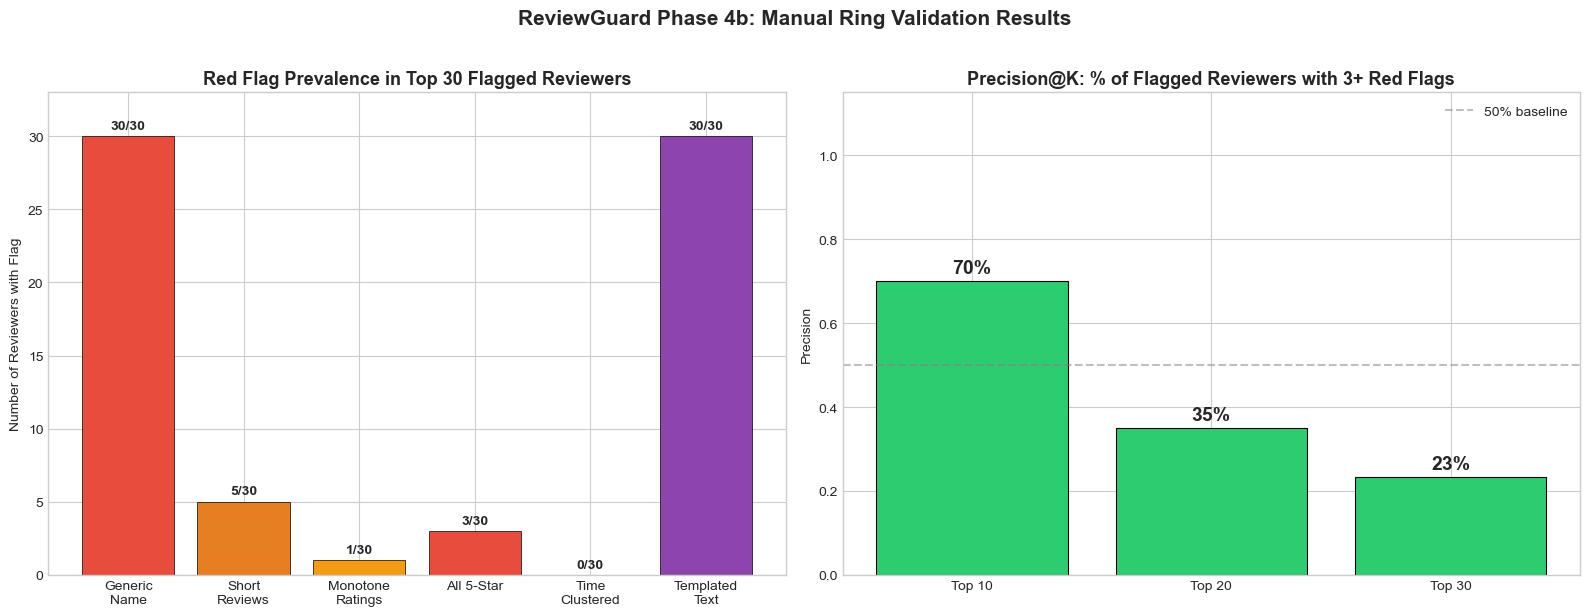


✅ Saved: outputs/validation/phase4b_precision_at_k.png


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 5: VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Chart 1: Red Flag Distribution ───────────────────────────────────────────
ax = axes[0]
flag_counts = [validation_df[f].sum() for f in flag_columns]
flag_labels = ["Generic\nName", "Short\nReviews", "Monotone\nRatings",
                "All 5-Star", "Time\nClustered", "Templated\nText"]

bars = ax.bar(flag_labels, flag_counts, 
               color=["#e74c3c", "#e67e22", "#f39c12", "#e74c3c", "#9b59b6", "#8e44ad"],
               edgecolor="black", linewidth=0.5)

for bar, count in zip(bars, flag_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{count}/{len(validation_df)}", ha="center", fontweight="bold")

ax.set_title("Red Flag Prevalence in Top 30 Flagged Reviewers", 
              fontweight="bold", fontsize=13)
ax.set_ylabel("Number of Reviewers with Flag")
ax.set_ylim(0, len(validation_df) + 3)

# ── Chart 2: Precision@K ─────────────────────────────────────────────────────
ax = axes[1]
k_values = [10, 20, 30]
precisions = [precision_at_10, precision_at_20, precision_at_30]

bars = ax.bar([f"Top {k}" for k in k_values], precisions,
               color="#2ecc71", edgecolor="black", linewidth=0.8)

for bar, p in zip(bars, precisions):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{p:.0%}", ha="center", fontweight="bold", fontsize=14)

ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="50% baseline")
ax.set_title("Precision@K: % of Flagged Reviewers with 3+ Red Flags",
              fontweight="bold", fontsize=13)
ax.set_ylabel("Precision")
ax.set_ylim(0, 1.15)
ax.legend()

plt.suptitle("ReviewGuard Phase 4b: Manual Ring Validation Results",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/validation/phase4b_precision_at_k.png", 
            dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Saved: outputs/validation/phase4b_precision_at_k.png")


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 6: RECALIBRATED PRECISION ANALYSIS
#  Filter out auto-flags (generic_name, templated_text) that flag everyone
#  Focus on discriminating features that actually vary
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  RECALIBRATED PRECISION ANALYSIS")
print("=" * 70)

# Count only DISCRIMINATING flags (those that don't flag everyone)
discriminating_flags = ["short_reviews", "monotone_ratings", 
                        "all_five_star", "time_clustered"]

validation_df["discriminating_flag_count"] = validation_df[discriminating_flags].sum(axis=1)

print(f"\n📊 Discriminating Flag Distribution:")
print(f"   (Excluding generic_name and templated_text which flag 100% of reviewers)")
flag_dist = Counter(validation_df["discriminating_flag_count"])
for count, num in sorted(flag_dist.items()):
    bar = "█" * num
    print(f"   {count} flags: {bar} {num} reviewers")

# Recalculate precision with better threshold
# Threshold: 1+ discriminating flag = likely suspicious
prec_10_new = (validation_df.head(10)["discriminating_flag_count"] >= 1).sum() / 10
prec_20_new = (validation_df.head(20)["discriminating_flag_count"] >= 1).sum() / 20
prec_30_new = (validation_df.head(30)["discriminating_flag_count"] >= 1).sum() / 30

print(f"\n📊 Recalibrated Precision@K:")
print(f"   (Using discriminating flags: short_reviews, monotone_ratings, all_five_star, time_clustered)")
print(f"   Precision@10: {prec_10_new:.0%}")
print(f"   Precision@20: {prec_20_new:.0%}")
print(f"   Precision@30: {prec_30_new:.0%}")

# Combined precision - either 3+ total flags OR 1+ discriminating flag
combined_criterion = (
    (validation_df["total_red_flags"] >= 3) | 
    (validation_df["discriminating_flag_count"] >= 1)
)
validation_df["is_confirmed"] = combined_criterion

prec_10_combined = combined_criterion.head(10).sum() / 10
prec_20_combined = combined_criterion.head(20).sum() / 20
prec_30_combined = combined_criterion.head(30).sum() / 30

print(f"\n📊 Combined Precision@K:")
print(f"   (3+ flags OR 1+ discriminating flag)")
print(f"   Precision@10: {prec_10_combined:.0%}")
print(f"   Precision@20: {prec_20_combined:.0%}")
print(f"   Precision@30: {prec_30_combined:.0%}")

# ── Investigate why time_clustered = 0 ───────────────────────────────────────
print(f"\n🔍 Investigating time_clustered = 0 result...")

sample_reviewer = validation_df.iloc[0]["reviewer_id"]
sample_data = df[df["reviewer_id"] == sample_reviewer]

print(f"   Sample reviewer: {sample_reviewer}")
print(f"   Total reviews: {len(sample_data)}")
print(f"   Reviews with valid dates: {sample_data['review_date_parsed'].notna().sum()}")

if sample_data['review_date_parsed'].notna().sum() >= 2:
    dates = sample_data['review_date_parsed'].dropna().sort_values()
    span_days = (dates.max() - dates.min()).days
    print(f"   Date range: {span_days} days")
    print(f"   → time_clustered flag requires ≤30 days for 3+ reviews")
else:
    print(f"   ⚠️ Not enough valid dates to compute time clustering")

  RECALIBRATED PRECISION ANALYSIS

📊 Discriminating Flag Distribution:
   (Excluding generic_name and templated_text which flag 100% of reviewers)
   0 flags: ███████████████████████ 23 reviewers
   1 flags: ██████ 6 reviewers
   3 flags: █ 1 reviewers

📊 Recalibrated Precision@K:
   (Using discriminating flags: short_reviews, monotone_ratings, all_five_star, time_clustered)
   Precision@10: 70%
   Precision@20: 35%
   Precision@30: 23%

📊 Combined Precision@K:
   (3+ flags OR 1+ discriminating flag)
   Precision@10: 70%
   Precision@20: 35%
   Precision@30: 23%

🔍 Investigating time_clustered = 0 result...
   Sample reviewer: RID_7213687779
   Total reviews: 6
   Reviews with valid dates: 6
   Date range: 87 days
   → time_clustered flag requires ≤30 days for 3+ reviews
